In [1]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy




In [2]:
from keras.datasets.mnist import load_data


(X_train, y_train), (X_test, y_test) = load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_dev, y_train, y_dev = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [5]:
X_train_reshaped = X_train.reshape(-1, 784)
X_dev_reshaped = X_dev.reshape(-1, 784)
X_test_reshaped = X_test.reshape(-1, 784)

In [6]:
from tensorflow.keras.utils import to_categorical
y_train_new = to_categorical(y_train,num_classes=10)
y_dev_new = to_categorical(y_dev, num_classes = 10)

In [7]:
from keras.models import Sequential


model = Sequential()
model.add(Dense(784, input_shape=(784, ), activation='relu'))
model.add(Dense(10, input_shape=(10, ), activation='sigmoid'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
from tensorflow.keras.optimizers import SGD

In [58]:
optimizer = SGD(learning_rate=0.01)

In [77]:
loss = BinaryCrossentropy()

In [14]:
model.compile(
    optimizer=optimizer,  # Hoặc optimizer='adam'
    loss=loss,  # Hoặc 'categorical_crossentropy' nếu y là one-hot
    metrics=['accuracy']
)

In [15]:
history = model.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=128, epochs=30)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7941 - loss: 5.6702 - val_accuracy: 0.9127 - val_loss: 0.1192
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9276 - loss: 0.0852 - val_accuracy: 0.9327 - val_loss: 0.0848
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9469 - loss: 0.0542 - val_accuracy: 0.9417 - val_loss: 0.0728
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9587 - loss: 0.0392 - val_accuracy: 0.9412 - val_loss: 0.0677
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9654 - loss: 0.0316 - val_accuracy: 0.9460 - val_loss: 0.0647
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9702 - loss: 0.0268 - val_accuracy: 0.9502 - val_loss: 0.0623
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9734 - loss: 0.0232 - val_accuracy: 0.9505 - val_loss: 0.0599
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9783 - loss: 0.0194 - val_accuracy: 0.

In [17]:
import matplotlib.pyplot as plt

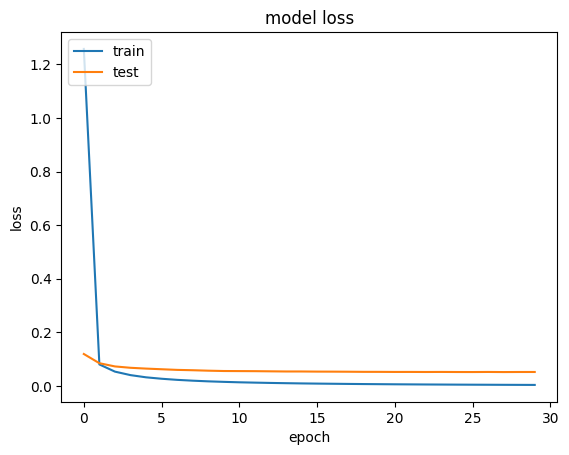

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

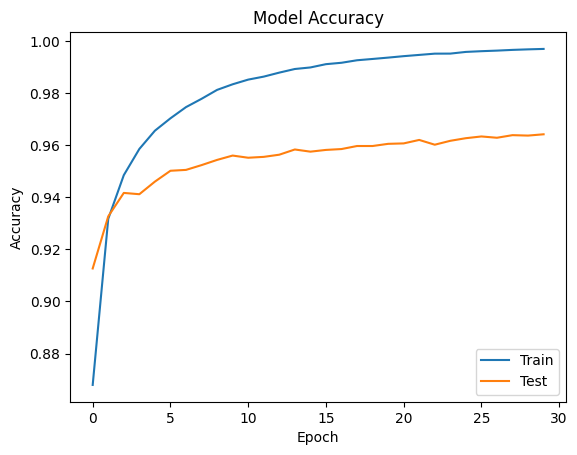

In [22]:
import matplotlib.pyplot as plt

# Vẽ đồ thị accuracy
plt.plot(history.history['accuracy'], label='Train')  # Đường accuracy tập train
plt.plot(history.history['val_accuracy'], label='Test')  # Đường accuracy tập validation
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')  # Hiển thị chú thích ở góc dưới phải
plt.show()

### Bài 2: Thực hiện huấn luyện mô hình mạng neural ở bài 1 với kỹ thuật regularization cho tham số W và b với lamda là 0.01. Cho biết kết quả huấn luyện mô hình trước và sau khi áp dụng kỹ thuật regularization (Dựa vào đồ thị học).

In [24]:
from tensorflow.keras.regularizers import l2


In [35]:
from keras.models import Sequential


model2 = Sequential()
model2.add(Dense(784, input_shape=(784, ), kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01), activation='relu'))
model2.add(Dense(10, input_shape=(10, ), kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01), activation='sigmoid'))


In [36]:
model2.compile(
    optimizer=SGD(learning_rate=0.01),  # hoặc SGD(0.01)
    loss=BinaryCrossentropy(),          # hoặc 'binary_crossentropy'
    metrics=['accuracy']
)

In [37]:
history2 = model2.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=128, epochs=30)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7910 - loss: 14.2960 - val_accuracy: 0.9125 - val_loss: 6.9841
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9298 - loss: 6.6724 - val_accuracy: 0.9317 - val_loss: 5.8741
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9516 - loss: 5.6124 - val_accuracy: 0.9427 - val_loss: 4.9546
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9610 - loss: 4.7338 - val_accuracy: 0.9478 - val_loss: 4.1842
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9677 - loss: 3.9968 - val_accuracy: 0.9517 - val_loss: 3.5352
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9735 - loss: 3.3761 - val_accuracy: 0.9563 - val_loss: 2.9887
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 2.8537 - val_accuracy: 0.9597 - val_loss: 2.5276
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9790 - loss: 2.4126 - val_accuracy: 0

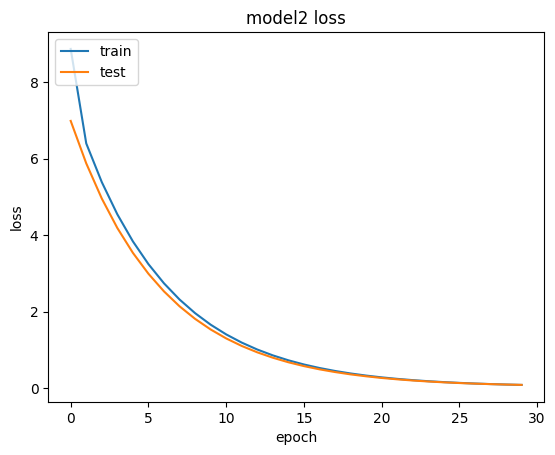

In [39]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model2 loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

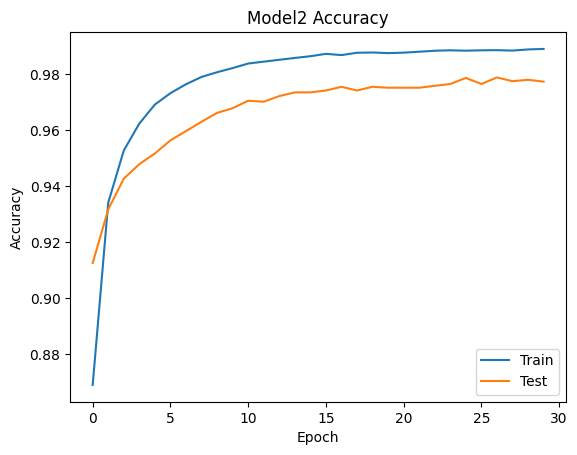

In [41]:
import matplotlib.pyplot as plt

# Vẽ đồ thị accuracy
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Test')
plt.title('Model2 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

### Bài 3: Thực hiện huấn luyện mô hình mạng neural ở bài 1 với kỹ thuật khởi tạo tham số cho tham số W. Nếu sử dụng kỹ thuật khởi tạo tham số là 1 cho tham số W thì kết quả độ chính xác mô hình như thế nào?

In [43]:
from tensorflow.keras.initializers import GlorotUniform, Zeros


In [47]:
from keras.models import Sequential


model3 = Sequential()
model3.add(Dense(784, input_shape=(784, ), kernel_initializer=GlorotUniform(), bias_initializer=Zeros, activation='relu') )
model3.add(Dense(10, input_shape=(10, ),activation='sigmoid'))


In [48]:
model3.compile(
    optimizer=SGD(learning_rate=0.01),  # hoặc SGD(0.01)
    loss=BinaryCrossentropy(),          # hoặc 'binary_crossentropy'
    metrics=['accuracy']
)

In [49]:
history3 = model3.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=128, epochs=30)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8053 - loss: 3.7986 - val_accuracy: 0.9258 - val_loss: 0.1229
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9411 - loss: 0.0887 - val_accuracy: 0.9388 - val_loss: 0.0908
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9585 - loss: 0.0529 - val_accuracy: 0.9443 - val_loss: 0.0760
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9675 - loss: 0.0386 - val_accuracy: 0.9477 - val_loss: 0.0694
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9722 - loss: 0.0298 - val_accuracy: 0.9512 - val_loss: 0.0653
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9785 - loss: 0.0224 - val_accuracy: 0.9523 - val_loss: 0.0631
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9818 - loss: 0.0191 - val_accuracy: 0.9543 - val_loss: 0.0620
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9849 - loss: 0.0153 - val_accuracy: 0.

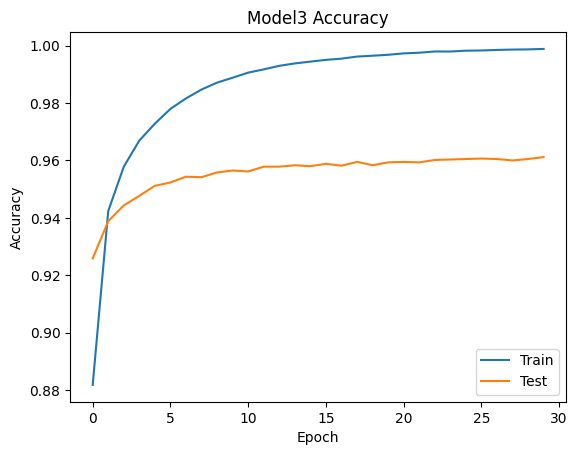

In [50]:
import matplotlib.pyplot as plt

# Vẽ đồ thị accuracy
plt.plot(history3.history['accuracy'], label='Train')
plt.plot(history3.history['val_accuracy'], label='Test')
plt.title('Model3 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

### **Bài 4: Thực hiện huấn luyện mô hình mạng neural ở bài 2 (đã áp dụng regularization) với thuật toán optimizer RMSProp và Adam. So sánh kết quả giữa 2 thuật toán.**

In [51]:
from keras.models import Sequential


model2 = Sequential()
model2.add(Dense(784, input_shape=(784, ), kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01), activation='relu'))
model2.add(Dense(10, input_shape=(10, ), kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01), activation='sigmoid'))


In [52]:
model2.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [53]:
history2_1 = model2.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=128, epochs=30)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3049 - loss: 26.0569 - val_accuracy: 0.4043 - val_loss: 2.7418
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4204 - loss: 2.1572 - val_accuracy: 0.5290 - val_loss: 1.1348
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5224 - loss: 0.9309 - val_accuracy: 0.6537 - val_loss: 0.7094
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7290 - loss: 0.5422 - val_accuracy: 0.8933 - val_loss: 0.3908
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8574 - loss: 0.3711 - val_accuracy: 0.9078 - val_loss: 0.3209
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9207 - loss: 0.3137 - val_accuracy: 0.9418 - val_loss: 0.2993
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9472 - loss: 0.2710 - val_accuracy: 0.9488 - val_loss: 0.2915
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9593 - loss: 0.2502 - val_accuracy: 0

In [54]:
model2.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [55]:
history2_2 = model2.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=128, epochs=30)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9631 - loss: 0.2001 - val_accuracy: 0.9600 - val_loss: 0.2425
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9677 - loss: 0.1942 - val_accuracy: 0.9602 - val_loss: 0.2391
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9664 - loss: 0.2019 - val_accuracy: 0.9642 - val_loss: 0.2274
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9685 - loss: 0.1949 - val_accuracy: 0.9612 - val_loss: 0.2292
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9671 - loss: 0.2034 - val_accuracy: 0.9595 - val_loss: 0.2405
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9694 - loss: 0.1909 - val_accuracy: 0.9557 - val_loss: 0.2483
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9679 - loss: 0.2009 - val_accuracy: 0.9567 - val_loss: 0.2540
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9695 - loss: 0.1913 - val_accuracy: 0.

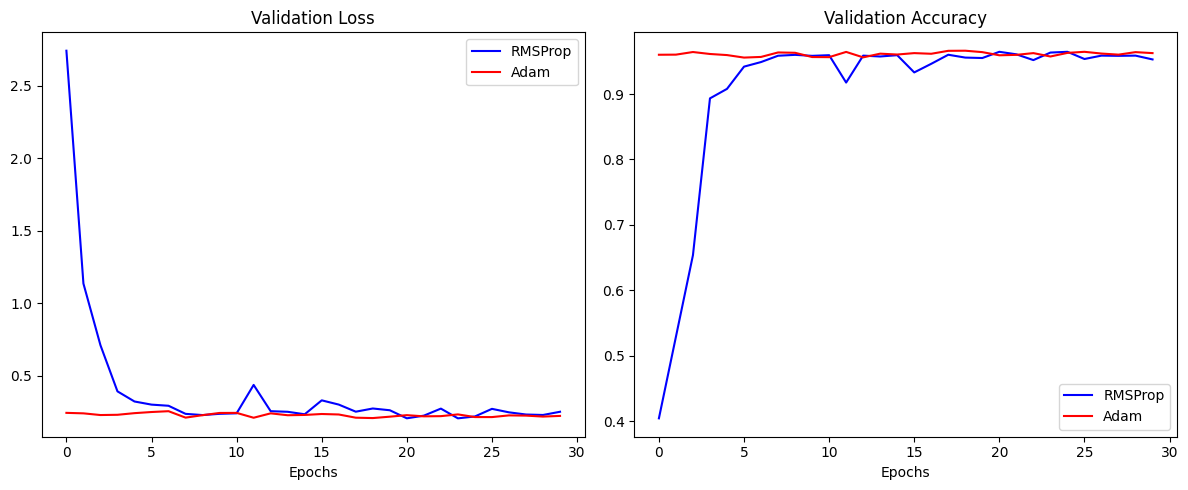

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# So sánh Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history2_1.history['val_loss'], label='RMSProp', color='blue')
plt.plot(history2_2.history['val_loss'], label='Adam', color='red')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.legend()

# So sánh Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history2_1.history['val_accuracy'], label='RMSProp', color='blue')
plt.plot(history2_2.history['val_accuracy'], label='Adam', color='red')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()

### **Hãy giảm batch size xuống 8 và huấn luyện mô hình mạng neural ở bài 2 (sử dụng optimizer SGD). Khi batch_size nhỏ thì có chuyện gì xảy ra (dựa vào đồ thị học).**

In [60]:
from keras.models import Sequential


model2 = Sequential()
model2.add(Dense(784, input_shape=(784, ), kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01), activation='relu'))
model2.add(Dense(10, input_shape=(10, ), kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01), activation='sigmoid'))


In [61]:
model2.compile(
    optimizer=optimizer,  # Hoặc optimizer='adam'
    loss=loss,  # Hoặc 'categorical_crossentropy' nếu y là one-hot
    metrics=['accuracy']
)

In [62]:
history5 = model2.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=8, epochs=30)

Epoch 1/30
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8629 - loss: 6.4458 - val_accuracy: 0.9438 - val_loss: 0.6327
Epoch 2/30
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9496 - loss: 0.3954 - val_accuracy: 0.9577 - val_loss: 0.0929
Epoch 3/30
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9557 - loss: 0.0789 - val_accuracy: 0.9595 - val_loss: 0.0575
Epoch 4/30
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9566 - loss: 0.0572 - val_accuracy: 0.9622 - val_loss: 0.0545
Epoch 5/30
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9589 - loss: 0.0550 - val_accuracy: 0.9558 - val_loss: 0.0561
Epoch 6/30
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9590 - loss: 0.0549 - val_accuracy: 0.9490 - val_loss: 0.0605
Epoch 7/30
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9574 - loss: 0.0558 - val_accuracy: 0.9498 - val_loss: 0.0616
Epoch 8/30
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9599 - loss: 0

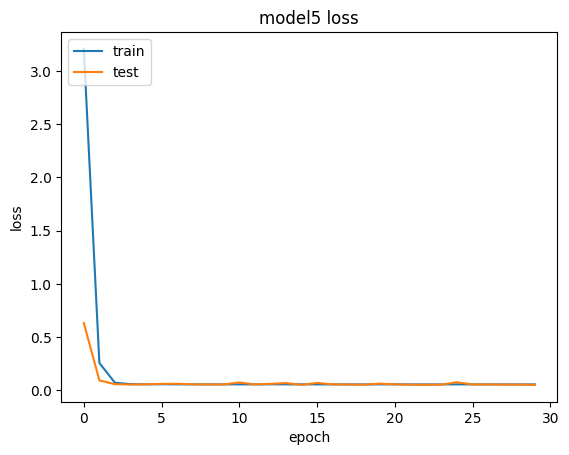

In [63]:
plt.plot(history5.history['loss'])
plt.plot(history5.history['val_loss'])
plt.title('model5 loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

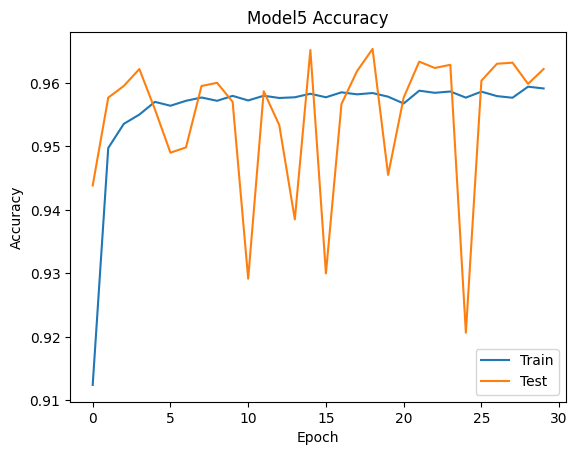

In [64]:
import matplotlib.pyplot as plt

# Vẽ đồ thị accuracy
plt.plot(history5.history['accuracy'], label='Train')
plt.plot(history5.history['val_accuracy'], label='Test')
plt.title('Model5 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

### **Bài 6: Hãy tăng epoch lên 100 và huấn luyện mô hình ở bài 5 với kỹ thuật Early Stoping (sử dụng monitor là val_loss). Cho biết kết quả.**

In [65]:
from keras.callbacks import EarlyStopping

In [66]:
callback = EarlyStopping(monitor="loss", patience=2)

In [68]:
history6 = model2.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=8, epochs=100,callbacks=[callback])

Epoch 1/100
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9604 - loss: 0.0549 - val_accuracy: 0.9657 - val_loss: 0.0512
Epoch 2/100
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9604 - loss: 0.0545 - val_accuracy: 0.9578 - val_loss: 0.0545
Epoch 3/100
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9596 - loss: 0.0543 - val_accuracy: 0.9617 - val_loss: 0.0538
Epoch 4/100
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9599 - loss: 0.0541 - val_accuracy: 0.9613 - val_loss: 0.0535


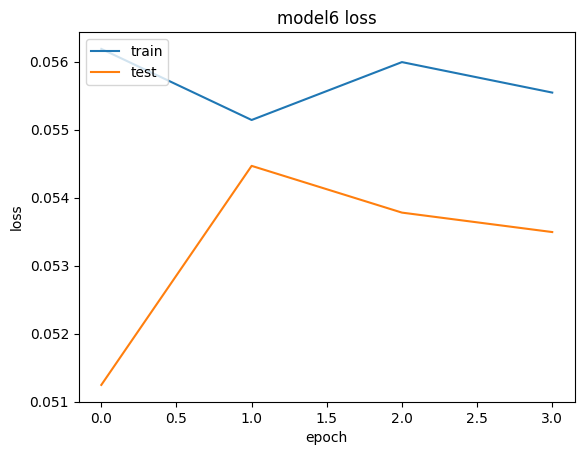

In [69]:
plt.plot(history6.history['loss'])
plt.plot(history6.history['val_loss'])
plt.title('model6 loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

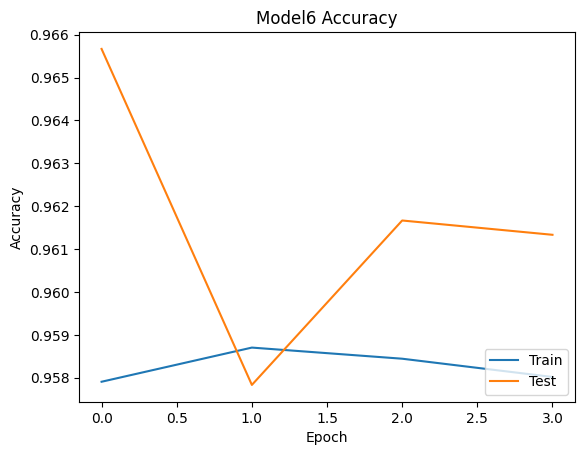

In [70]:
import matplotlib.pyplot as plt

# Vẽ đồ thị accuracy
plt.plot(history6.history['accuracy'], label='Train')
plt.plot(history6.history['val_accuracy'], label='Test')
plt.title('Model6 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

### **Bài 7: Thực hiện các yêu cầu từ Bài 1, Bài 2, Bài 6 với bộ dữ liệu CIFAR10.**

In [71]:
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 1. Tải dữ liệu CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. Chia train/dev
X_train, X_dev, y_train, y_dev = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# 3. Reshape lại: từ (32, 32, 3) → (3072,)
X_train_reshaped = X_train.reshape(-1, 32 * 32 * 3)
X_dev_reshaped = X_dev.reshape(-1, 32 * 32 * 3)
X_test_reshaped = X_test.reshape(-1, 32 * 32 * 3)


y_train_new = to_categorical(y_train, num_classes=10)
y_dev_new = to_categorical(y_dev, num_classes=10)
y_test_new = to_categorical(y_test, num_classes=10)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [72]:
X_train.shape

(45000, 32, 32, 3)

#### 7_1

In [85]:
from keras.models import Sequential


model7_1 = Sequential()
model7_1.add(Dense(3072, input_shape=(3072, ), activation='relu'))
model7_1.add(Dense(10, input_shape=(10, ), activation='sigmoid'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model7_1.compile(
    optimizer = SGD(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [87]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)


In [88]:
history7_1 = model7_1.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=128, epochs=30)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.1117 - loss: 1156.5223 - val_accuracy: 0.1212 - val_loss: 0.6307
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.1139 - loss: 0.6502 - val_accuracy: 0.1014 - val_loss: 0.6239
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.1076 - loss: 0.6265 - val_accuracy: 0.1030 - val_loss: 0.5893
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.1127 - loss: 0.5884 - val_accuracy: 0.1008 - val_loss: 0.5613
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1079 - loss: 0.5597 - val_accuracy: 0.1140 - val_loss: 0.5226
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1109 - loss: 0.5292 - val_accuracy: 0.0994 - val_loss: 0.5071
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.1071 - loss: 0.4982 - val_accuracy: 0.1138 - val_loss: 0.4851
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1106 - loss: 0.4774 - v

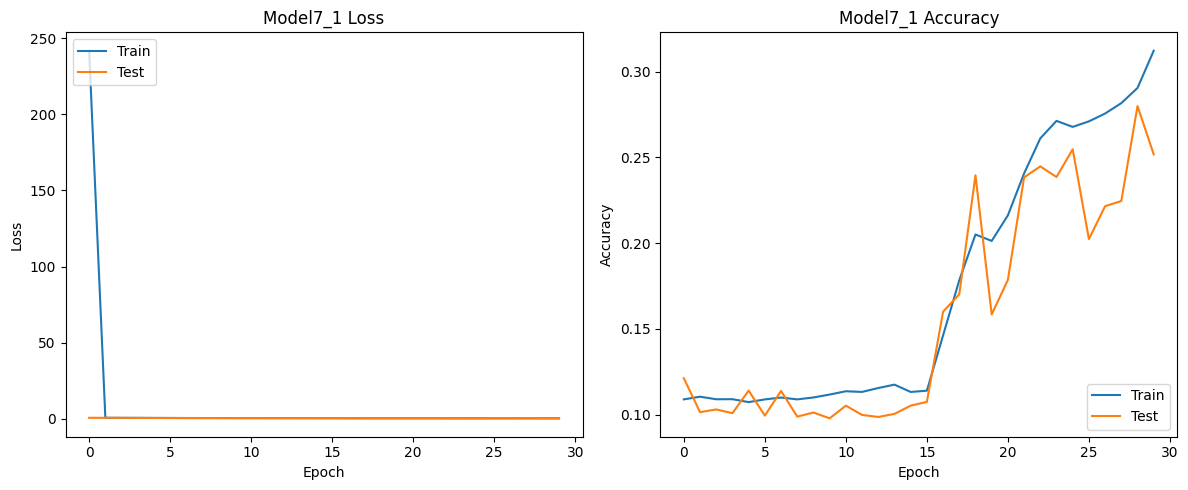

In [89]:
import matplotlib.pyplot as plt

# Thiết lập kích thước chung cho figure
plt.figure(figsize=(12, 5))

# Vẽ biểu đồ loss
plt.subplot(1, 2, 1)  # 1 hàng, 2 cột, vị trí 1
plt.plot(history7_1.history['loss'])
plt.plot(history7_1.history['val_loss'])
plt.title('Model7_1 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Vẽ biểu đồ accuracy
plt.subplot(1, 2, 2)  # 1 hàng, 2 cột, vị trí 2
plt.plot(history7_1.history['accuracy'])
plt.plot(history7_1.history['val_accuracy'])
plt.title('Model7_1 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='lower right')

# Hiển thị cả hai biểu đồ
plt.tight_layout()
plt.show()


In [91]:
from tensorflow.keras.layers import Dropout


In [92]:
model = Sequential()
model.add(Dense(1024, input_shape=(3072,), activation='relu', kernel_regularizer=l2(0.01)))  # Giảm units + L2 regularization
model.add(Dropout(0.5))  # Thêm Dropout
model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

# Compile với Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [93]:
history7_2 = model.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=128, epochs=30)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - accuracy: 0.1010 - loss: 139.9676 - val_accuracy: 0.0978 - val_loss: 18.2678
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.0972 - loss: 17.3720 - val_accuracy: 0.0952 - val_loss: 14.8069
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.0985 - loss: 14.1008 - val_accuracy: 0.1002 - val_loss: 12.1716
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.1001 - loss: 11.6084 - val_accuracy: 0.0952 - val_loss: 10.0604
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.1025 - loss: 9.6072 - val_accuracy: 0.0970 - val_loss: 8.3738
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.0986 - loss: 8.0457 - val_accuracy: 0.0952 - val_loss: 7.0378
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.0964 - loss: 6.7587 - val_accuracy: 0.0974 - val_loss: 5.9530
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.0978 - loss: 

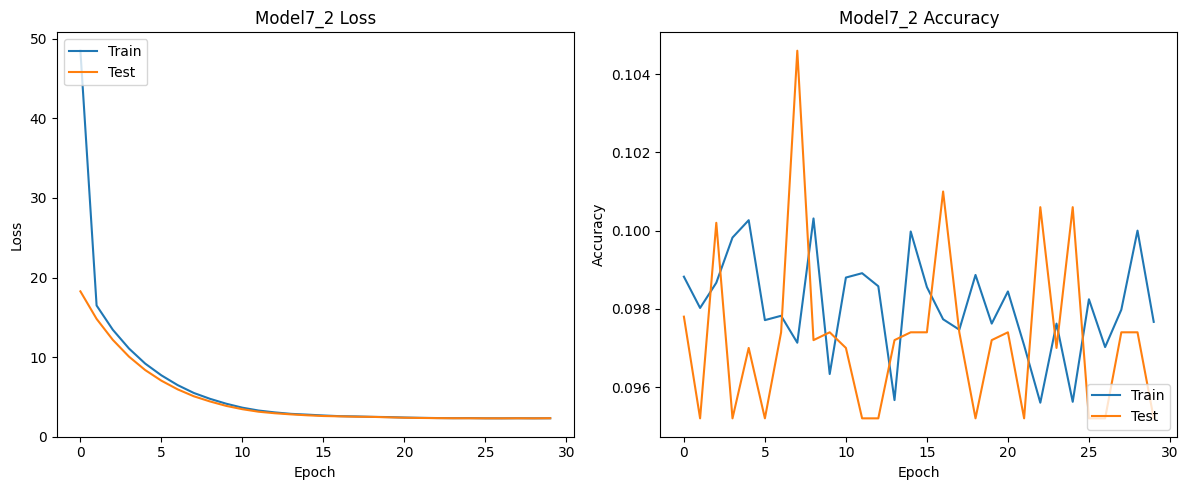

In [94]:
import matplotlib.pyplot as plt

# Thiết lập kích thước chung cho figure
plt.figure(figsize=(12, 5))

# Vẽ biểu đồ loss
plt.subplot(1, 2, 1)  # 1 hàng, 2 cột, vị trí 1
plt.plot(history7_2.history['loss'])
plt.plot(history7_2.history['val_loss'])
plt.title('Model7_2 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Vẽ biểu đồ accuracy
plt.subplot(1, 2, 2)  # 1 hàng, 2 cột, vị trí 2
plt.plot(history7_2.history['accuracy'])
plt.plot(history7_2.history['val_accuracy'])
plt.title('Model7_2 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='lower right')

# Hiển thị cả hai biểu đồ
plt.tight_layout()
plt.show()


In [95]:
history7_3 = model7_1.fit(X_train_reshaped, y_train_new, validation_data=(X_dev_reshaped,y_dev_new) ,batch_size=8, epochs=100,callbacks=[callback])

Epoch 1/100
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 135s 24ms/step - accuracy: 0.1111 - loss: 0.3746 - val_accuracy: 0.1000 - val_loss: 0.3386
Epoch 2/100
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 135s 24ms/step - accuracy: 0.1052 - loss: 0.3362 - val_accuracy: 0.1062 - val_loss: 0.3305
Epoch 3/100
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 138s 25ms/step - accuracy: 0.1087 - loss: 0.3273 - val_accuracy: 0.1050 - val_loss: 0.3272
Epoch 4/100
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 136s 24ms/step - accuracy: 0.1084 - loss: 0.3249 - val_accuracy: 0.1052 - val_loss: 0.3270
Epoch 5/100
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 145s 24ms/step - accuracy: 0.1078 - loss: 0.3241 - val_accuracy: 0.1090 - val_loss: 0.3258
Epoch 6/100
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 140s 24ms/step - accuracy: 0.1153 - loss: 0.3236 - val_accuracy: 0.1210 - val_loss: 0.3316
Epoch 7/100
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 130s 23ms/step - accuracy: 0.1125 - loss: 0.3238 - val_accuracy: 0.1070 - val_loss: 0.3266
Epoch 8/100
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 145s 24ms/step - ac

KeyboardInterrupt: 